# **Predicting Student Test Scores**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy


from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#Evaluation
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    mean_squared_error
)

In [35]:
train_data = pd.read_csv(r"/kaggle/input/student-score-test/train.csv")
eval_test_data = pd.read_csv(r"/kaggle/input/data-2/Exam_Score_Prediction.csv")
test_data = pd.read_csv(r"/kaggle/input/student-test-data/test.csv")

In [36]:
#train data
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [37]:
#Test Data
test_data.head(3) 

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate


In [38]:
# Data types information
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [39]:
# shape check
train_data.shape

(630000, 13)

In [40]:
# data summary
train_data.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


#### **Missing Value check**

In [41]:
# Missing value check
train_data.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [42]:
# Duplicates check
train_data.duplicated().sum()

0

In [43]:
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


#### **Encoding**

In [44]:
# onehot encode 
ohe = OneHotEncoder(drop='first')

train_data['internet_access'] =  ohe.fit_transform(train_data[['internet_access']]).toarray()

#label encode
le = LabelEncoder()
cols = ['gender', 'course', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

for col in cols:
    train_data[col] = le.fit_transform(train_data[col])

In [45]:
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,0,1,7.91,98.8,0.0,4.9,0,3,1,0,78.3
1,1,18,2,6,4.95,94.8,1.0,4.7,2,4,2,2,46.7
2,2,20,0,1,4.68,92.6,1.0,5.8,2,0,0,2,99.0
3,3,19,1,1,2.00,49.5,1.0,8.3,0,1,0,2,63.9
4,4,23,1,5,7.65,86.9,1.0,9.6,1,4,0,0,100.0


### **Data Visualization**

<Axes: >

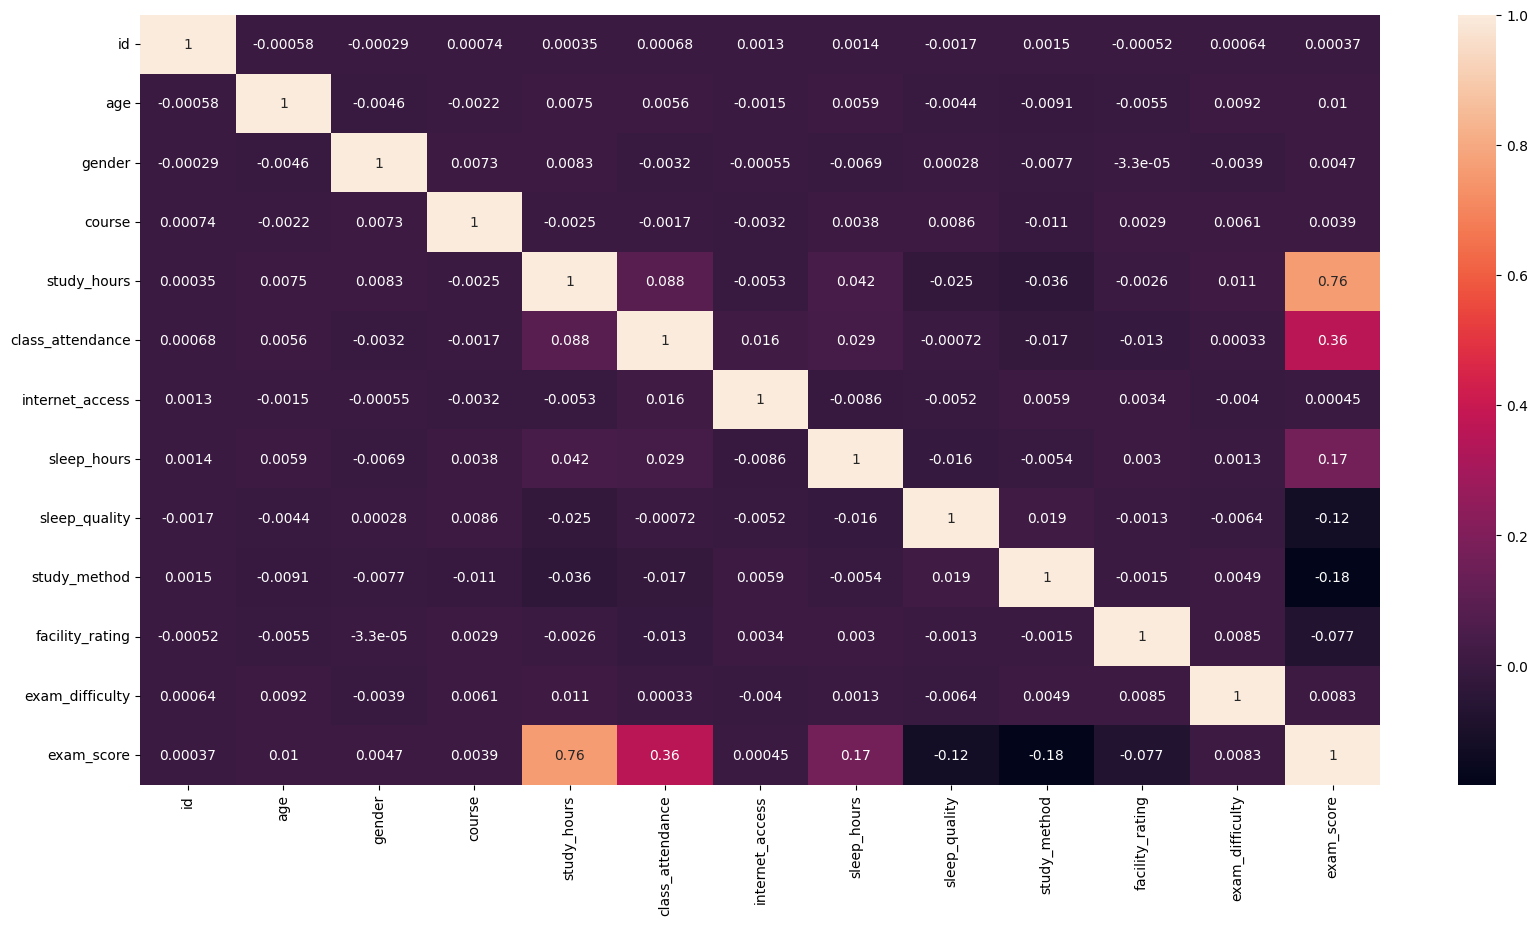

In [46]:
plt.figure(figsize=(20,10))
corr = train_data.corr()
sns.heatmap(corr, annot=True)

#### #Drop Column

In [47]:
# train_data.drop(columns=['id', 'gender', 'internet_access', 'facility_rating'], inplace=True)

In [48]:
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,0,1,7.91,98.8,0.0,4.9,0,3,1,0,78.3
1,1,18,2,6,4.95,94.8,1.0,4.7,2,4,2,2,46.7
2,2,20,0,1,4.68,92.6,1.0,5.8,2,0,0,2,99.0
3,3,19,1,1,2.00,49.5,1.0,8.3,0,1,0,2,63.9
4,4,23,1,5,7.65,86.9,1.0,9.6,1,4,0,0,100.0


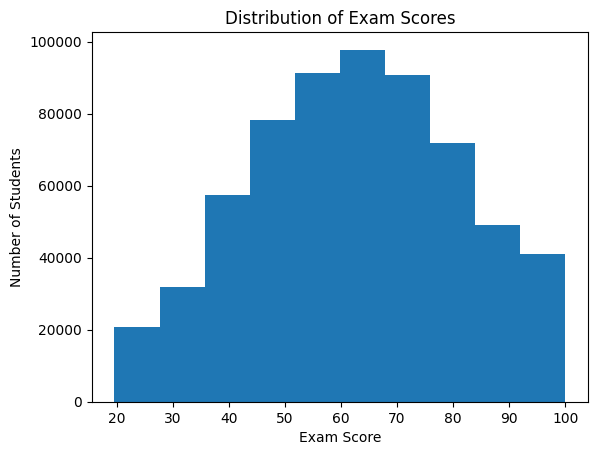

In [49]:
plt.hist(train_data["exam_score"], bins=10)
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")
plt.show()


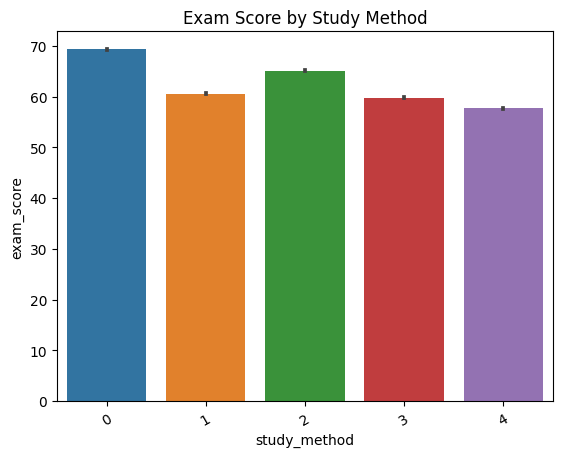

In [50]:
sns.barplot(x="study_method", y="exam_score", data=train_data)
plt.xticks(rotation=30)
plt.title("Exam Score by Study Method")
plt.show()


### **Data Scaling**

In [51]:
# ss = StandardScaler()

# train_data = pd.DataFrame(ss.fit_transform(train_data), columns=train_data.columns)

In [52]:
# scale = FunctionTransformer(func=np.log1p)
# train_data = scale.fit_transform(train_data)

In [53]:
train_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,0,1,7.91,98.8,0.0,4.9,0,3,1,0,78.3
1,1,18,2,6,4.95,94.8,1.0,4.7,2,4,2,2,46.7
2,2,20,0,1,4.68,92.6,1.0,5.8,2,0,0,2,99.0
3,3,19,1,1,2.00,49.5,1.0,8.3,0,1,0,2,63.9
4,4,23,1,5,7.65,86.9,1.0,9.6,1,4,0,0,100.0


### **Outlier Detection**

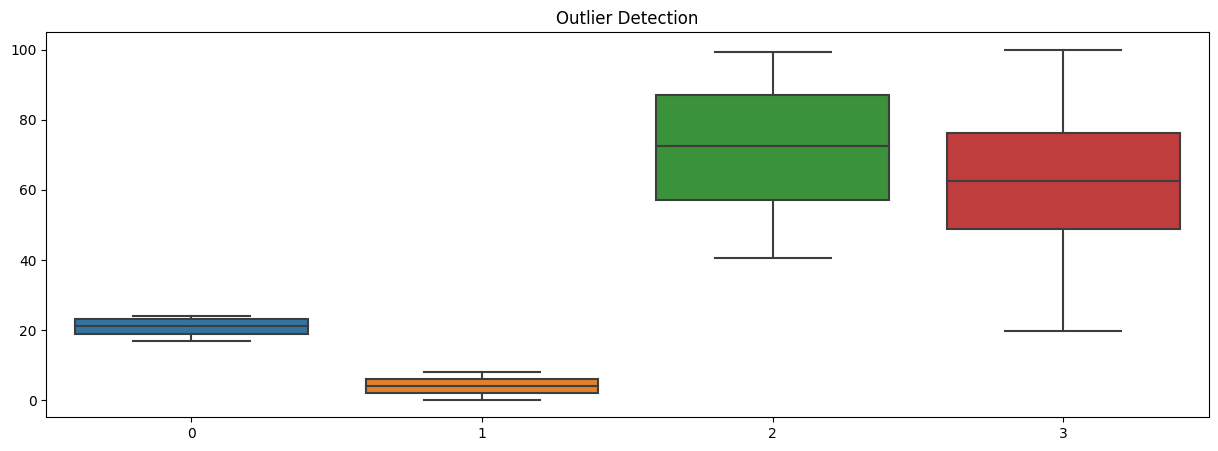

In [54]:
plt.figure(figsize=(15,5))
sns.boxplot([train_data['age'], train_data['study_hours'], train_data['class_attendance'], train_data['exam_score']])
plt.title("Outlier Detection")
plt.show()


In [55]:
x = train_data.iloc[:, :-1]
y = train_data[['exam_score']]

### Train Test split

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42)

### **Model**

In [ ]:
d

### Cross validation

In [ ]:
cross_val_score(estimator=XGBRegressor(), X=x_train, y=y_train, cv=KFold(n_splits=50))

In [ ]:
cross_val_score(estimator=LGBMRegressor(), X=x_train, y=y_train, cv=KFold(n_splits=50))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 851
[LightGBM] [Info] Number of data points in the train set: 308700, number of used features: 12
[LightGBM] [Info] Start training from score 62.453104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 850
[LightGBM] [Info] Number of data points in the train set: 308700, number of used features: 12
[LightGBM] [Info] Start training from score 62.462179
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno

array([0.78813691, 0.77506616, 0.77796539, 0.78267897, 0.78357265,
       0.78395299, 0.77451587, 0.78242516, 0.78401807, 0.78674401,
       0.78174335, 0.77776603, 0.79074853, 0.78836691, 0.77851847,
       0.78236859, 0.78003382, 0.78370411, 0.77776612, 0.7871074 ,
       0.79020392, 0.78241024, 0.77528829, 0.78872499, 0.78025506,
       0.78356155, 0.78376021, 0.78495716, 0.78714699, 0.77962465,
       0.78091167, 0.77674289, 0.78332687, 0.78329754, 0.78538463,
       0.77826053, 0.77335526, 0.7864949 , 0.78241276, 0.78722857,
       0.7888386 , 0.78440832, 0.7806536 , 0.7803648 , 0.77952607,
       0.77039946, 0.78119382, 0.7852095 , 0.78705715, 0.78271623])

In [ ]:
cross_val_score(estimator=CatBoostRegressor(), X=x_train, y=y_train, cv=KFold(n_splits=50))

Learning rate set to 0.101281
0:	learn: 17.6840302	total: 77.2ms	remaining: 1m 17s
1:	learn: 16.5837985	total: 98.6ms	remaining: 49.2s
2:	learn: 15.6200903	total: 120ms	remaining: 39.7s
3:	learn: 14.7896329	total: 139ms	remaining: 34.7s
4:	learn: 14.0543649	total: 161ms	remaining: 31.9s
5:	learn: 13.4279811	total: 184ms	remaining: 30.4s
6:	learn: 12.8716091	total: 204ms	remaining: 28.9s
7:	learn: 12.3844359	total: 224ms	remaining: 27.8s
8:	learn: 11.9629569	total: 243ms	remaining: 26.8s
9:	learn: 11.6016721	total: 263ms	remaining: 26.1s
10:	learn: 11.2820261	total: 283ms	remaining: 25.4s
11:	learn: 10.9956038	total: 302ms	remaining: 24.9s
12:	learn: 10.7512842	total: 322ms	remaining: 24.5s
13:	learn: 10.5381610	total: 343ms	remaining: 24.1s
14:	learn: 10.3536533	total: 361ms	remaining: 23.7s
15:	learn: 10.1893618	total: 381ms	remaining: 23.4s
16:	learn: 10.0441813	total: 401ms	remaining: 23.2s
17:	learn: 9.9159887	total: 421ms	remaining: 23s
18:	learn: 9.8028324	total: 440ms	remaining:

array([0.79099474, 0.77756987, 0.78028197, 0.78417388, 0.78592922,
       0.78586018, 0.77708515, 0.78445384, 0.78582266, 0.78966862,
       0.78405443, 0.78089358, 0.79317416, 0.79083393, 0.78056117,
       0.78469693, 0.78208647, 0.78546466, 0.78065879, 0.78953359,
       0.79196034, 0.78397298, 0.77843573, 0.79128077, 0.78234831,
       0.78669944, 0.7867656 , 0.78695193, 0.78935777, 0.78178314,
       0.78311506, 0.77782519, 0.78423504, 0.7854788 , 0.78631103,
       0.78029638, 0.77608666, 0.78851796, 0.78496608, 0.78994277,
       0.79068446, 0.78748368, 0.78222092, 0.78291191, 0.78240225,
       0.77334289, 0.78316386, 0.78678426, 0.78864589, 0.78460307])

#### HyperParameter tuning

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11],
    'learning_rate': [0.01, 0.1, 0.2],
    'colsample_bytree': [0.7, 0.8, 0.9]
}



In [ ]:
hyper_param_tun = RandomizedSearchCV(estimator=XGBRegressor(), param_distributions=param_grid, n_iter=5)
hyper_param_tun.fit(x_train, y_train)

RandomizedSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None,...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=5,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(f"Parameter: {hyper_param_tun.best_params_}")
print(f"MSE score: {hyper_param_tun.best_score_}") 

Parameter: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
MSE score: 0.7824407157422006


#### XGBoostRegression

In [58]:
xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.1, colsample_bytree=0.7)
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [59]:
print(f"Train score: {xgb.score(x_train, y_train)*100}")
print(f"Test score: {xgb.score(x_test, y_test)*100}")

Train score: 78.36178802834846
Test score: 78.21145824324492


### **Evaluation Model**

In [60]:
eval_test_data.rename(columns={"student_id": "id"}, inplace=True)

#Data preprocessing
ohe = OneHotEncoder(drop='first')
eval_test_data['internet_access'] =  ohe.fit_transform(eval_test_data[['internet_access']]).toarray()

le = LabelEncoder()
cols = ['gender', 'course', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

for col in cols:
    eval_test_data[col] = le.fit_transform(eval_test_data[col])

x_eval = eval_test_data.iloc[:, :-1]
y_eval = eval_test_data['exam_score']


#Prediction
y_prd_eval = xgb.predict(x_eval)


#MES error
print(f"MSE loss: {mean_squared_error(y_eval, y_prd_eval)}")



MSE loss: 95.93304795141825


#### **Final Submission**

In [61]:
test_data.shape

(270000, 12)

In [62]:
ohe = OneHotEncoder(drop='first')

test_data['internet_access'] =  ohe.fit_transform(test_data[['internet_access']]).toarray()

le = LabelEncoder()
cols = ['gender', 'course', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

for col in cols:
    test_data[col] = le.fit_transform(test_data[col])

In [63]:
test_data.head(3)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,2,3,6.85,65.2,1.0,5.2,2,1,0,0
1,630001,18,1,6,6.61,45.0,0.0,9.3,2,0,1,0
2,630002,24,0,2,6.60,98.5,1.0,6.2,1,1,2,2


In [65]:
y_prd = xgb.predict(test_data)
final_sub = pd.DataFrame({"id": test_data['id'], "exam_score": y_prd})
final_sub.to_csv("3.submission.csv", index=False)

In [66]:
final_sub

,id,exam_score
0,630000,72.010384
1,630001,70.044266
2,630002,87.823341
3,630003,54.644012
4,630004,46.318848
...,...,...
269995,899995,60.266159
269996,899996,39.699505
269997,899997,90.680481
269998,899998,55.875515
